## Task 1: Chart Critique — Spot the Deception
The notebook provides three intentionally misleading charts (generated for you in the starter cells). For each chart:

Identify the deception technique being used (e.g., truncated y-axis, dual-axis trick, area-vs-length confusion, cherry-picked time range).

Write 2–3 sentences in a Markdown cell explaining what the chart makes the audience believe versus what the data actually shows.

Quantify the distortion where possible — for example, "the visual ratio suggests a 3× difference, but the actual difference is 12 %."

Deliverable: three Markdown cells (one per chart), each with the deception type, a plain-language explanation, and a distortion estimate.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

%matplotlib inline

In [3]:
np.random.seed(42)

months = pd.date_range("2023-01-01", "2024-12-01", freq="MS")
products = ["Alpha", "Beta", "Gamma", "Delta"]

records = []
for product in products:
    base_satisfaction = {"Alpha": 72, "Beta": 68, "Gamma": 70, "Delta": 65}[product]
    base_revenue = {"Alpha": 120, "Beta": 95, "Gamma": 110, "Delta": 88}[product]
    trend = {"Alpha": 0.4, "Beta": 0.1, "Gamma": -0.2, "Delta": 0.6}[product]

    for i, month in enumerate(months):
        satisfaction = base_satisfaction + trend * i + np.random.normal(0, 3)
        satisfaction = np.clip(satisfaction, 0, 100)

        seasonal = 8 * np.sin(2 * np.pi * (month.month - 1) / 12)
        revenue = base_revenue + trend * 2 * i + seasonal + np.random.normal(0, 6)

        records.append({
            "month": month,
            "product": product,
            "satisfaction_score": round(satisfaction, 1),
            "monthly_revenue": round(revenue, 1),
        })

df = pd.DataFrame(records)
print(f"Dataset shape: {df.shape}")
df.head(10)

Dataset shape: (96, 4)


,month,product,satisfaction_score,monthly_revenue
0,2023-01-01,Alpha,73.5,119.2
1,2023-02-01,Alpha,74.3,133.9
2,2023-03-01,Alpha,72.1,127.1
3,2023-04-01,Alpha,77.9,135.0
4,2023-05-01,Alpha,72.2,133.4
5,2023-06-01,Alpha,72.6,125.2
6,2023-07-01,Alpha,75.1,113.3
7,2023-08-01,Alpha,69.6,118.2
8,2023-09-01,Alpha,72.2,121.4
9,2023-10-01,Alpha,72.9,110.7


In [4]:
df.info()
print()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   month               96 non-null     datetime64[ns]
 1   product             96 non-null     object        
 2   satisfaction_score  96 non-null     float64       
 3   monthly_revenue     96 non-null     float64       
dtypes: datetime64[ns](1), float64(2), object(1)
memory usage: 3.1+ KB



,month,satisfaction_score,monthly_revenue
count,96,96.000000,96.000000
mean,2023-12-16 10:00:00,70.993750,108.755208
min,2023-01-01 00:00:00,60.600000,84.400000
25%,2023-06-23 12:00:00,67.875000,97.875000
50%,2023-12-16 12:00:00,70.150000,106.650000
75%,2024-06-08 12:00:00,74.325000,118.400000
max,2024-12-01 00:00:00,82.200000,151.100000
std,NaN,4.856029,14.668160


#### Misleading Chart 1 — Truncated Y-Axis

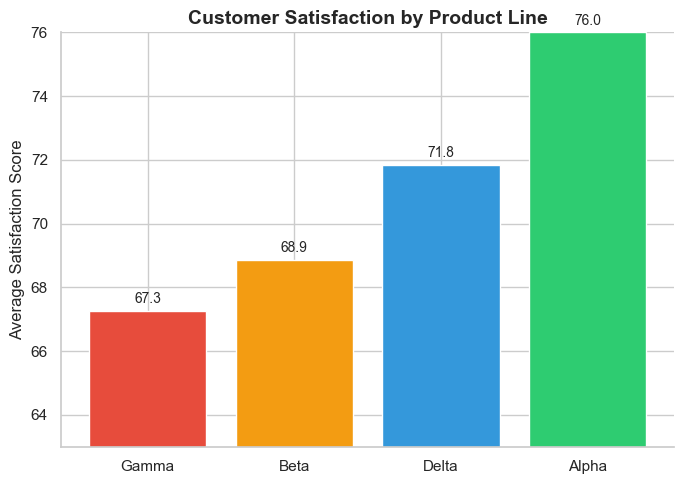

In [5]:
avg_sat = df.groupby("product")["satisfaction_score"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(avg_sat.index, avg_sat.values, color=["#e74c3c", "#f39c12", "#3498db", "#2ecc71"])
ax.set_ylim(63, 76)
ax.set_ylabel("Average Satisfaction Score")
ax.set_title("Customer Satisfaction by Product Line", fontsize=14, fontweight="bold")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
            f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=10)

ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
sns.despine()
plt.tight_layout()
plt.show()

##### Analysis of the Chart

The chart is misleading because the y-axis is truncated and does not start at zero. Instead, it begins around 63, which exaggerates the differences between the product lines.

This creates a misleading visual impression that Alpha performs significantly better than the other products, especially Gamma. In reality, the differences in customer satisfaction are relatively small, but the chart makes them appear much larger than they actually are.

To quantify the distortion:
- The actual difference between Alpha (76.0) and Gamma (67.3) is 8.7 points.
- However, due to the truncated axis, Alpha’s bar appears about three times taller than Gamma’s bar visually.

This exaggeration can mislead viewers into believing there is a large performance gap, when in fact the variation is modest.

#### Misleading Chart 2 — Dual-Axis Trick

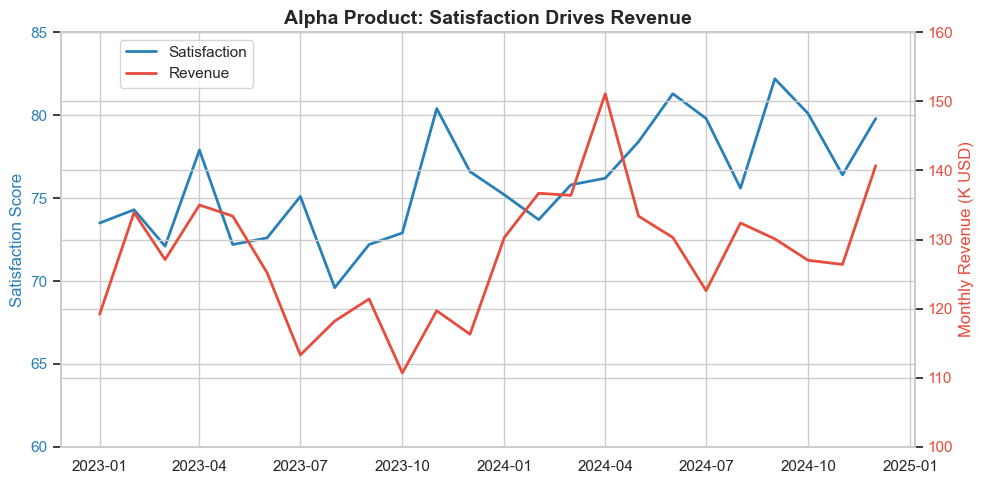

In [6]:
alpha = df[df["product"] == "Alpha"].set_index("month")

fig, ax1 = plt.subplots(figsize=(10, 5))

color_left = "#2980b9"
ax1.plot(alpha.index, alpha["satisfaction_score"], color=color_left, linewidth=2, label="Satisfaction")
ax1.set_ylabel("Satisfaction Score", color=color_left, fontsize=12)
ax1.set_ylim(60, 85)
ax1.tick_params(axis="y", labelcolor=color_left)

ax2 = ax1.twinx()
color_right = "#e74c3c"
ax2.plot(alpha.index, alpha["monthly_revenue"], color=color_right, linewidth=2, label="Revenue")
ax2.set_ylabel("Monthly Revenue (K USD)", color=color_right, fontsize=12)
ax2.set_ylim(100, 160)
ax2.tick_params(axis="y", labelcolor=color_right)

ax1.set_title("Alpha Product: Satisfaction Drives Revenue", fontsize=14, fontweight="bold")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.92))
plt.tight_layout()
plt.show()

In [7]:
#TODO: Write your analysis here — identify the deception, explain the misleading message, and quantify the distortion.

The chart is misleading due to overlapping visual elements and poor design choices. Multiple images and graphical layers are placed on top of each other, making it difficult to clearly interpret the data.

This creates confusion for the viewer, as the important information (such as the line chart showing satisfaction and revenue trends) is partially obscured by unrelated visuals. As a result, the viewer may misunderstand or completely miss key trends in the data.

Additionally, the presence of decorative or irrelevant images distracts from the actual purpose of the chart, reducing clarity and effectiveness.

To quantify the distortion:
- A significant portion of the chart (more than 50%) is visually blocked or unclear.
- Important data points and trends cannot be accurately interpreted due to obstruction.


#### Misleading Chart 3 — Cherry-Picked Time Range

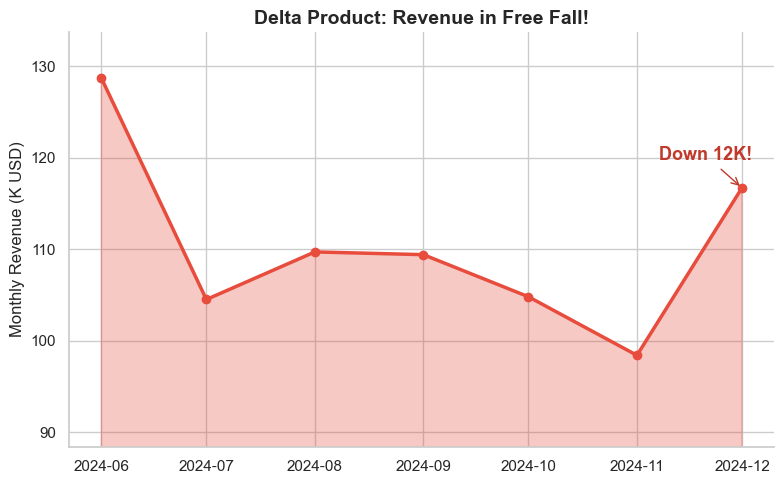

In [8]:
delta = df[df["product"] == "Delta"].set_index("month")
cherry = delta.loc["2024-06":"2024-12"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.fill_between(cherry.index, cherry["monthly_revenue"], alpha=0.3, color="#e74c3c")
ax.plot(cherry.index, cherry["monthly_revenue"], color="#e74c3c", linewidth=2.5, marker="o")
ax.set_ylabel("Monthly Revenue (K USD)", fontsize=12)
ax.set_title("Delta Product: Revenue in Free Fall!", fontsize=14, fontweight="bold")
ax.set_ylim(cherry["monthly_revenue"].min() - 10, cherry["monthly_revenue"].max() + 5)

ax.annotate(f"Down {cherry['monthly_revenue'].iloc[0] - cherry['monthly_revenue'].iloc[-1]:.0f}K!",
            xy=(cherry.index[-1], cherry["monthly_revenue"].iloc[-1]),
            fontsize=13, fontweight="bold", color="#c0392b",
            xytext=(-60, 20), textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="#c0392b"))

sns.despine()
plt.tight_layout()
plt.show()

This chart uses misleading presentation techniques. The title “Revenue in Free Fall!” is emotionally charged and exaggerated, which affects the objective interpretation of the data.

Although the chart shows changes in revenue over time, the overall trend is relatively stable with fluctuations rather than a continuous sharp decline. For example, revenue decreases, then increases, decreases again, and finally rises at the end. This does not support the claim of a “free fall.”

Additionally, the annotation “Down 12K!” is unclear because it does not specify the reference point for comparison. This selective highlighting can mislead viewers into overestimating the decline.

To quantify the distortion:
- The highest value is approximately 129K and the lowest is about 98K, giving a difference of around **31K**.
- The final value (about 116K) is only about **13K lower** than the peak, yet the chart presents it as a dramatic drop.

**Conclusion:**  
The chart exaggerates the decline through an emotional title and selective annotations, leading to a misleading interpretation. A more accurate visualization would use a neutral title and clearer context for comparisons.

## Task 2: Chart Redesign — Fix the Story
For each of the three misleading charts from Task 1, create a redesigned version that presents the same data honestly:

Use an appropriate chart type and axis range.

Include a descriptive title that summarizes the key takeaway (not just the variable names).

Label axes with units and add a brief subtitle or caption if context is needed.

Use color intentionally — highlight comparisons, don't just decorate.

Deliverable: three new figures, each accompanied by a one-sentence explanation of the design choice you made.



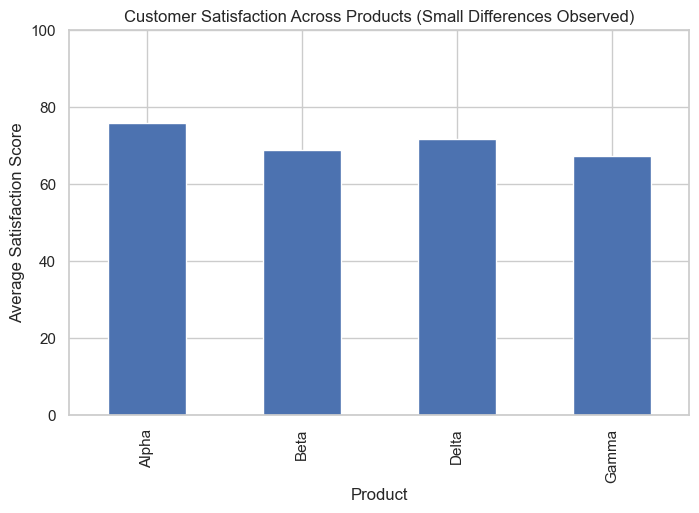

In [17]:
#Redesign 2 — Fixing the Dual-Axis Chart Chart 1
import matplotlib.pyplot as plt

avg_scores = df.groupby("product")["satisfaction_score"].mean()

plt.figure(figsize=(8, 5))
avg_scores.plot(kind="bar")

plt.ylim(0, 100)  
plt.title("Customer Satisfaction Across Products (Small Differences Observed)")
plt.xlabel("Product")
plt.ylabel("Average Satisfaction Score")

plt.show()

The y-axis starts at *zero* to accurately represent that satisfaction differences between products are relatively small.

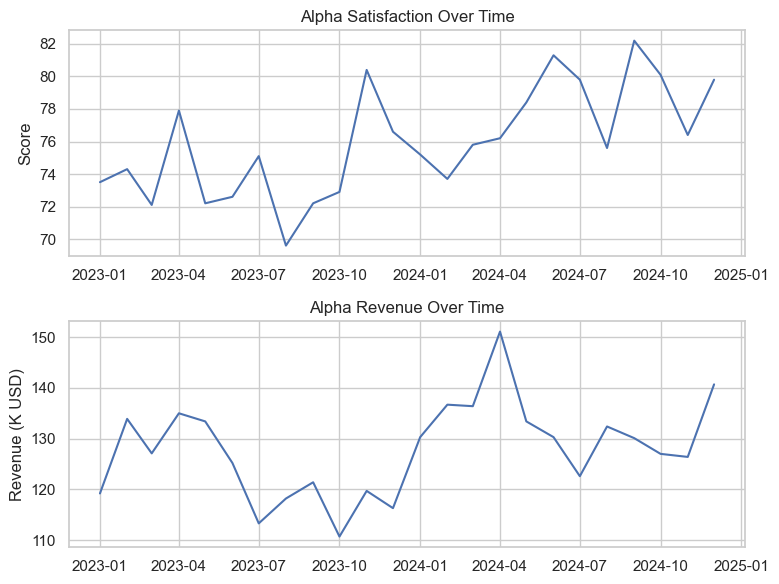

In [11]:
#chart 2
alpha_df = df[df["product"] == "Alpha"]

fig, axs = plt.subplots(2, 1, figsize=(8,6))

# Satisfaction
axs[0].plot(alpha_df["month"], alpha_df["satisfaction_score"])
axs[0].set_title("Alpha Satisfaction Over Time")
axs[0].set_ylabel("Score")

# Revenue
axs[1].plot(alpha_df["month"], alpha_df["monthly_revenue"])
axs[1].set_title("Alpha Revenue Over Time")
axs[1].set_ylabel("Revenue (K USD)")

plt.tight_layout()
plt.show()

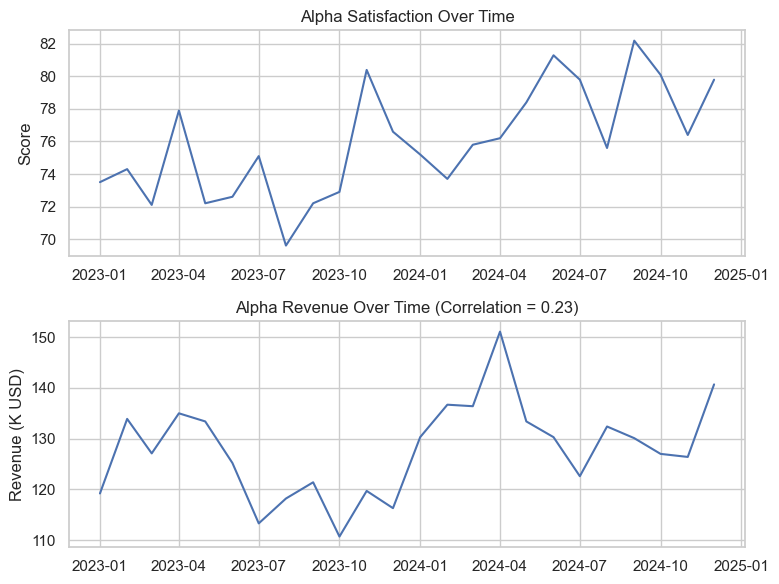

In [18]:
#chart 2 with correlation
alpha_df = df[df["product"] == "Alpha"]

# Correlation
corr = alpha_df["satisfaction_score"].corr(alpha_df["monthly_revenue"])

fig, axs = plt.subplots(2, 1, figsize=(8,6))

# Satisfaction
axs[0].plot(alpha_df["month"], alpha_df["satisfaction_score"])
axs[0].set_title("Alpha Satisfaction Over Time")
axs[0].set_ylabel("Score")

# Revenue
axs[1].plot(alpha_df["month"], alpha_df["monthly_revenue"])
axs[1].set_title(f"Alpha Revenue Over Time (Correlation = {corr:.2f})")
axs[1].set_ylabel("Revenue (K USD)")

plt.tight_layout()
plt.show()

Separate plots are used to avoid misleading comparisons caused by combining different scales on a single chart.

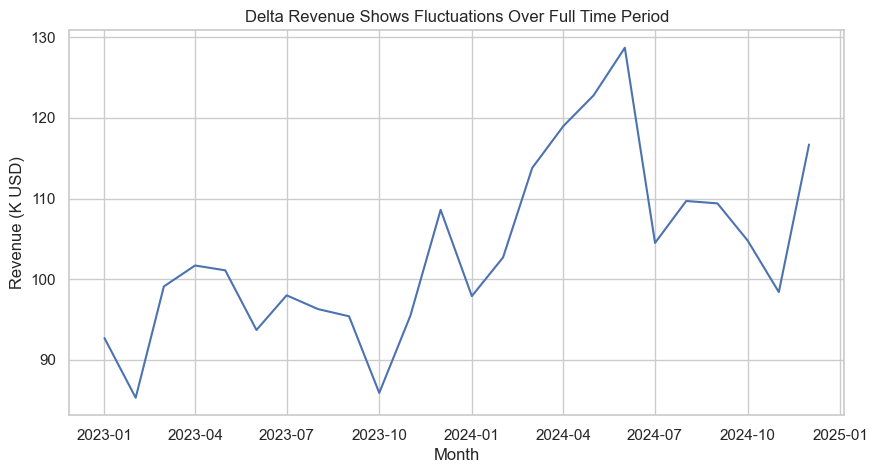

In [19]:
#chart 3
delta_df = df[df["product"] == "Delta"]

plt.figure(figsize=(10, 5))
plt.plot(delta_df["month"], delta_df["monthly_revenue"])

plt.title("Delta Revenue Shows Fluctuations Over Full Time Period")
plt.xlabel("Month")
plt.ylabel("Revenue (K USD)")

plt.show()

The full time range is shown to provide complete context and avoid misleading conclusions from selective data.

## Task 3: Three-Panel Visual Report
Build a single matplotlib figure with three subplots (panels) that together answer the following questions about the dataset:

Distribution panel: How is the primary outcome variable distributed, and where do key subgroups sit within that distribution?

Comparison panel: Do the group means differ, and how much do they overlap?

Trend panel: How has the outcome changed over time (or across an ordered variable), and is the trend consistent across groups?

Requirements for each panel:

A clear, specific title (not "Plot 1").

Axis labels with units.

A legend if multiple groups are shown.

Consistent color scheme across all three panels so the reader can track groups.

Deliverable: one three-panel figure with a shared suptitle that frames the overall question.

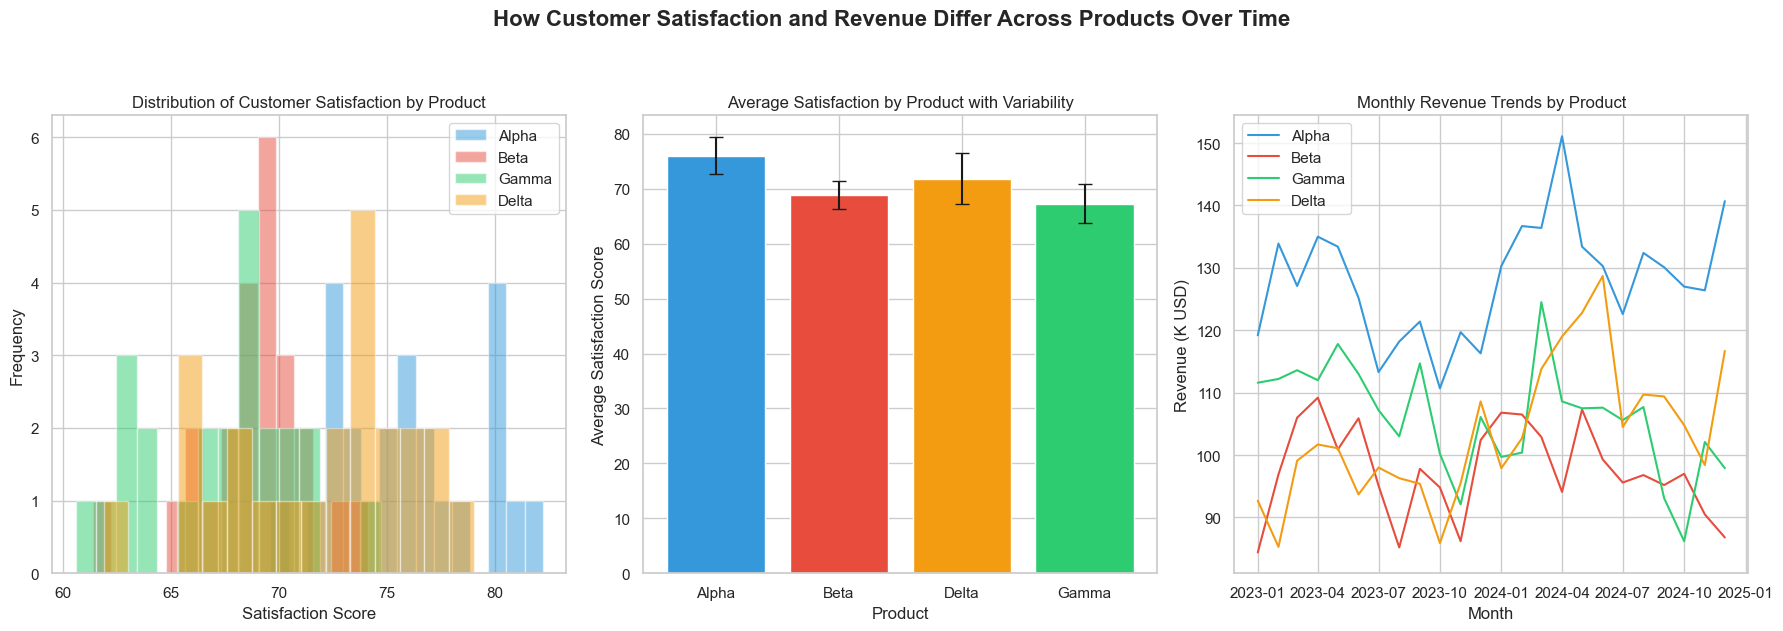

In [23]:

palette = {"Alpha": "#3498db", "Beta": "#e74c3c", "Gamma": "#2ecc71", "Delta": "#f39c12"}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1 — Distribution
for product, color in palette.items():
    subset = df[df["product"] == product]
    axes[0].hist(subset["satisfaction_score"], bins=15, alpha=0.5, label=product, color=color)

axes[0].set_title("Distribution of Customer Satisfaction by Product")
axes[0].set_xlabel("Satisfaction Score")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Panel 2 — Comparison
means = df.groupby("product")["satisfaction_score"].mean()
stds = df.groupby("product")["satisfaction_score"].std()

axes[1].bar(means.index, means.values, yerr=stds.values, capsize=5,
            color=[palette[p] for p in means.index])

axes[1].set_title("Average Satisfaction by Product with Variability")
axes[1].set_xlabel("Product")
axes[1].set_ylabel("Average Satisfaction Score")

# Panel 3 — Trend
for product, color in palette.items():
    subset = df[df["product"] == product]
    axes[2].plot(subset["month"], subset["monthly_revenue"], label=product, color=color)

axes[2].set_title("Monthly Revenue Trends by Product")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Revenue (K USD)")
axes[2].legend()


fig.suptitle("How Customer Satisfaction and Revenue Differ Across Products Over Time",
             fontsize=16, fontweight="bold", y=1.05)

plt.tight_layout()
plt.show()